## Train AlexNet on MNIST Dataset

In [16]:
# Install torchvision if not already present
# !pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### 1. Data Loading and Transformation

AlexNet expects input images of size 224x224. MNIST images are 28x28, so we need to resize and convert them to 3 channels (AlexNet is trained on RGB images, MNIST is grayscale). We'll repeat the grayscale channel 3 times to simulate RGB.

In [17]:
# Define transformations for the MNIST dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet input size
    transforms.Grayscale(num_output_channels=3), # Convert to 3 channels for AlexNet
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


### 2. Load Pre-trained AlexNet and Modify Classifier

We load a pre-trained AlexNet model from `torchvision.models`. Since AlexNet was trained on ImageNet (1000 classes), we need to replace its final classification layer with a new one that outputs 10 classes for MNIST.

In [18]:
# Load pre-trained AlexNet model
model = models.alexnet(pretrained=True)

# Freeze feature parameters (optional, good for fine-tuning with small datasets)
# for param in model.features.parameters():
#     param.requires_grad = False

# Modify the classifier for MNIST (10 classes)
num_ftrs = model.classifier[6].in_features
print("num_ftrs ", num_ftrs)
model.classifier[6] = nn.Linear(num_ftrs, 10)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

num_ftrs  4096


### 3. Training and Testing the Model

Now we'll define the training and testing functions. The training function will iterate over the training data, perform a forward pass, calculate the loss, backpropagate, and update the model's weights. The testing function will evaluate the model's accuracy on the test dataset.

In [19]:
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad() # Clear gradients
        output = model(data) # Forward pass
        loss = criterion(output, target) # Compute loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
    avg_loss = running_loss / len(train_loader)
    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}')
    return avg_loss

def test(model, device, test_loader, criterion):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() # Sum up batch loss
            pred = output.argmax(dim=1, keepdim=True) # Get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')
    return test_loss, 100. * correct / len(test_loader.dataset)

### 4. Run Training Loop

We'll train the model for a few epochs and record the training and testing loss, and accuracy.

In [20]:
num_epochs = 5 # You can increase this for better performance

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):
    train_loss = train(model, device, train_loader, optimizer, criterion, epoch)
    test_loss, test_accuracy = test(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

print("Training complete!")

torch.Size([64, 3, 224, 224])
0
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.588096
torch.Size([64, 3, 224, 224])
1
torch.Size([64, 3, 224, 224])
2
torch.Size([64, 3, 224, 224])
3
torch.Size([64, 3, 224, 224])
4
torch.Size([64, 3, 224, 224])
5
torch.Size([64, 3, 224, 224])
6
torch.Size([64, 3, 224, 224])
7
torch.Size([64, 3, 224, 224])
8
torch.Size([64, 3, 224, 224])
9
torch.Size([64, 3, 224, 224])
10
torch.Size([64, 3, 224, 224])
11
torch.Size([64, 3, 224, 224])
12
torch.Size([64, 3, 224, 224])
13
torch.Size([64, 3, 224, 224])
14
torch.Size([64, 3, 224, 224])
15
torch.Size([64, 3, 224, 224])
16
torch.Size([64, 3, 224, 224])
17
torch.Size([64, 3, 224, 224])
18
torch.Size([64, 3, 224, 224])
19
torch.Size([64, 3, 224, 224])
20
torch.Size([64, 3, 224, 224])
21
torch.Size([64, 3, 224, 224])
22
torch.Size([64, 3, 224, 224])
23
torch.Size([64, 3, 224, 224])
24
torch.Size([64, 3, 224, 224])
25
torch.Size([64, 3, 224, 224])
26
torch.Size([64, 3, 224, 224])
27
torch.Size([64, 3, 224, 224])
28
torch.Si

### 5. Plotting Results

Visualize the training and testing loss, and test accuracy over epochs.

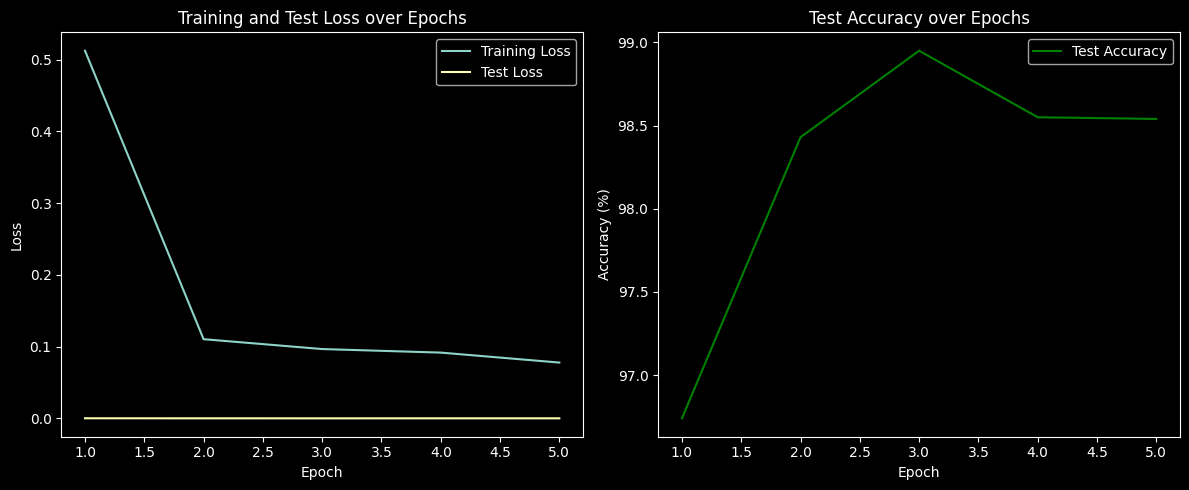

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()